In [ ]:
import sys
!pip install scikit-learn   # metrike (RMSE, MAE)
!pip install arch           # GARCH model
!{sys.executable} -m pip install pandas     # rad sa tabelama
!{sys.executable} -m pip install matplotlib # grafici

In [3]:
import pandas as pd                                          
import matplotlib.pyplot as plt                             # crtanje grafika
import numpy as np                                          # numericke operacije
import warnings                                             # iskljucivanje upozorenja
from sklearn.metrics import mean_squared_error, mean_absolute_error  # metrike greske
from statsmodels.tsa.holtwinters import ExponentialSmoothing         # Holt-Winters model
from arch import arch_model                                          # GARCH model
from statsmodels.tsa.arima.model import ARIMA                        # ARIMA model
from statsmodels.tsa.ar_model import AutoReg                         # AR model
from pathlib import Path                                             # rad sa putanjama fajlova
warnings.filterwarnings("ignore")                                    # iskljuci upozorenja

In [24]:
# Lista tikera koje ucitavamo
vector_stocks=[
        "AAPL", "MSFT", "AMZN", "GOOGL", "JPM", "JNJ", "XOM", "PG", "KO", "PEP",
        "WMT", "INTC", "CSCO", "ORCL", "IBM", "CVX", "MRK", "PFE", "T", "VZ",
        "HD", "MCD", "NKE", "DIS", "BA", "CAT", "GS", "MMM", "WFC", "C",
    ]

# Putanja do foldera sa CSV fajlovima
folder_stocks=Path("C:/Users/Kristina/Desktop/efmproj/stocks")  ############ STAVITE SVOJU ADRESU ############

# Ucitavamo svaki CSV kao DataFrame i cuvamo u recniku {ticker: DataFrame}
baze_stocks={
    ticker: pd.read_csv(folder_stocks / f"{ticker}.csv", parse_dates=["Date"])  # parse_dates parsira kolonu Date kao datum
    for ticker in vector_stocks
}

In [25]:
# Filtriranje — zadrzavamo samo period od 2010-01-01 do 2020-04-01
start_date = "2010-01-01"
end_date = "2020-04-01"

baze_stocks = {
    ticker: df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()  # .copy() da se izbegne SettingWithCopyWarning
    for ticker, df in baze_stocks.items()
}

In [26]:
# Provera dimenzija nakon filtriranja
for k, df in baze_stocks.items():
    print(k, df.shape)

AAPL (2579, 7)
MSFT (2579, 7)
AMZN (2579, 7)
GOOGL (2579, 7)
JPM (2579, 7)
JNJ (2579, 7)
XOM (2579, 7)
PG (2579, 7)
KO (2579, 7)
PEP (2579, 7)
WMT (2579, 7)
INTC (2579, 7)
CSCO (2579, 7)
ORCL (2579, 7)
IBM (2579, 7)
CVX (2579, 7)
MRK (2579, 7)
PFE (2579, 7)
T (2579, 7)
VZ (2579, 7)
HD (2579, 7)
MCD (2579, 7)
NKE (2579, 7)
DIS (2579, 7)
BA (2579, 7)
CAT (2580, 7)
GS (2579, 7)
MMM (2579, 7)
WFC (2579, 7)
C (2579, 7)


In [27]:
# Pravimo liste vremenskih serija — zadrzavamo samo Date i Adj Close kolone
# Adj Close je cena prilagodjena dividendama i splitovima — pravi prinos investitora
baze_stocks_ts = {
    ticker: (
        df.loc[
            (df["Date"] >= start_date) & (df["Date"] <= end_date),
            ["Date", "Adj Close"]   # uzimamo samo ove dve kolone
        ]
        .sort_values("Date")        # sortiramo hronoloski
        .reset_index(drop=True)     # resetujemo indeks na 0,1,2...
    )
    for ticker, df in baze_stocks.items()
}

In [28]:
# Funkcija za podelu na trening i test skup
# Train: 2010-01-04 do 2020-03-16 (pre COVID-kraha)
# Test:  2020-03-17 do 2020-04-01 (COVID-krah — stres-test)
def split_train_test(df):
    df = df.copy()
    
    # Ako Date nije indeks nego kolona, postavi ga kao indeks
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])         # konvertuj u datetime
        df = df.sort_values("Date").set_index("Date")   # postavi Date kao indeks
    
    # Eksplicitno filtriranje po datumu (pouzdanije od string slicinga)
    train = df[(df.index >= "2010-01-04") & (df.index <= "2020-03-16")]
    test  = df[(df.index >= "2020-03-17") & (df.index <= "2020-04-01")]

    return train, test

# Primenjujemo split na sve tikere
stocks_train = {}   # recnik trening skupova
stocks_test  = {}   # recnik test skupova

for ticker, df in baze_stocks_ts.items():
    tr, te = split_train_test(df)
    stocks_train[ticker] = tr
    stocks_test[ticker]  = te

# Provera ispravnosti splita
print(stocks_test["AAPL"].index.min())   # treba da bude 2020-03-17
print(stocks_test["AAPL"].index.max())   # treba da bude 2020-04-01
print(len(stocks_test["AAPL"]), "dana u test skupu")

2020-03-17 00:00:00
2020-04-01 00:00:00
12 dana u test skupu


In [29]:
#DEFINISEMO NEOPHODNE METRIKE
def rmse(actual, price_paths):
    """
    Root Mean Squared Error.
    actual      : np.array [H] — stvarne cene
    price_paths : np.array [S, H] — Monte Carlo putanje u cenama
    """
    pred = np.median(price_paths, axis=0)  # medijana putanja [H]
    return np.sqrt(np.mean((actual - pred) ** 2))


def nd(actual, price_paths):
    """
    Normalized Deviation.
    ND = sum|actual - pred| / sum|actual|
    Vrednost 0.1 znaci prosecno 10% greske.
    """
    pred = np.median(price_paths, axis=0)
    return np.sum(np.abs(actual - pred)) / np.sum(np.abs(actual))


def ql(actual, price_paths, rho):
    """
    Quantile Loss normalizovan.
    rho = 0.9 -> gornji percentil (optimisticni scenario)
    rho = 0.1 -> donji percentil  (pesimisticni scenario, kljucno za VaR)
    """
    q = np.percentile(price_paths, rho * 100, axis=0)  # [H]
    err = actual - q
    loss = np.where(err >= 0, rho * err, (rho - 1) * err)
    return 2 * np.mean(loss) / np.mean(np.abs(actual))


def get_price_paths(samples, last_price, je_cene=False):
    """
    Pomocna funkcija — pretvara log-prinose u cene.
    je_cene=True za Holt-Winters koji vec vraca cene.
    """
    if je_cene:
        return samples
    return last_price * np.exp(np.cumsum(samples, axis=1))


In [10]:
####################################### R A N D O M   W A L K #####################################
stocks_rw_preds   = {}   # cuva deterministicku predikciju po tikeru
stocks_rw_samples = {}   # cuva Monte Carlo uzorke po tikeru
def get_log_returns(df):
    return np.log(df["Adj Close"] / df["Adj Close"].shift(1)).dropna()  # shift(1) daje prethodnu vrednost
    
for ticker in stocks_train:
    ret_train = get_log_returns(stocks_train[ticker]).reset_index(drop=True)  # log-prinosi iz train skupa
    
    sigma = float(ret_train.std())   # standardna devijacija log-prinosa (naucena iz traina)
    H = len(stocks_test[ticker])     # horizont = broj dana u test skupu
    
    # Deterministicka predikcija — RW nema drift, ocekivana vrednost prinosa = 0
    stocks_rw_preds[ticker] = np.zeros(H)
    
    # Monte Carlo simulacija
    rng = np.random.default_rng(42)              # fiksirani seed za reproduktibilnost
    S = 1000                                      # broj putanja
    n_windows = max(1, H // 21)                  # broj rolling polazista
    samples = np.zeros((n_windows, S, H))        # matrica uzoraka [polazista x putanje x dani]
    
    for w in range(n_windows):
        samples[w] = rng.normal(loc=0.0, scale=sigma, size=(S, H))  # svaki prinos ~ N(0, sigma^2)
    
    stocks_rw_samples[ticker] = samples

print("\nSvi Random Walk modeli gotovi.")


Svi Random Walk modeli gotovi.


In [ ]:
#METRIKE RANDOM WALK
print("=== RANDOM WALK ===")
rw_rezultati = []

for ticker in stocks_test:
    actual     = stocks_test[ticker]["Adj Close"].values
    last_price = float(stocks_test[ticker]["Adj Close"].iloc[0])
    paths      = get_price_paths(stocks_rw_samples[ticker][0], last_price)

    m = {
        "Ticker": ticker,
        "RMSE":   round(rmse(actual, paths), 4),
        "ND":     round(nd(actual, paths), 4),
        "QL_0.9": round(ql(actual, paths, 0.9), 4),
        "QL_0.1": round(ql(actual, paths, 0.1), 4),
    }
    print(f"  {ticker}: RMSE={m['RMSE']}  ND={m['ND']}  QL0.9={m['QL_0.9']}  QL0.1={m['QL_0.1']}")
    rw_rezultati.append(m)

df_rw = pd.DataFrame(rw_rezultati).set_index("Ticker")
print(f"\n  PROSEK: RMSE={df_rw['RMSE'].mean():.4f}  ND={df_rw['ND'].mean():.4f}  "
      f"QL0.9={df_rw['QL_0.9'].mean():.4f}  QL0.1={df_rw['QL_0.1'].mean():.4f}\n")

=== RANDOM WALK ===
  AAPL: RMSE=12.0606  ND=0.0357  QL0.9=0.0175  QL0.1=0.0245
  MSFT: RMSE=7.7443  ND=0.0433  QL0.9=0.0152  QL0.1=0.0223
  AMZN: RMSE=104.3941  ND=0.0484  QL0.9=0.0053  QL0.1=0.0208
  GOOGL: RMSE=32.9896  ND=0.0235  QL0.9=0.0112  QL0.1=0.0117
  JPM: RMSE=7.3202  ND=0.0661  QL0.9=0.0235  QL0.1=0.0589
  JNJ: RMSE=12.8635  ND=0.0842  QL0.9=0.024  QL0.1=0.0989
  XOM: RMSE=2.4798  ND=0.0522  QL0.9=0.0149  QL0.1=0.0546
  PG: RMSE=11.4623  ND=0.0885  QL0.9=0.025  QL0.1=0.106
  KO: RMSE=5.4773  ND=0.1111  QL0.9=0.0295  QL0.1=0.1419
  PEP: RMSE=12.5867  ND=0.0896  QL0.9=0.0251  QL0.1=0.1084
  WMT: RMSE=5.5188  ND=0.0412  QL0.9=0.016  QL0.1=0.0216
  INTC: RMSE=3.3699  ND=0.0564  QL0.9=0.0212  QL0.1=0.0315
  CSCO: RMSE=3.0037  ND=0.0669  QL0.9=0.0413  QL0.1=0.0219
  ORCL: RMSE=2.1569  ND=0.0383  QL0.9=0.0115  QL0.1=0.0153
  IBM: RMSE=5.9498  ND=0.0431  QL0.9=0.0135  QL0.1=0.0364
  CVX: RMSE=8.5897  ND=0.0947  QL0.9=0.0291  QL0.1=0.1174
  MRK: RMSE=3.9382  ND=0.0445  QL0.9=0.0151

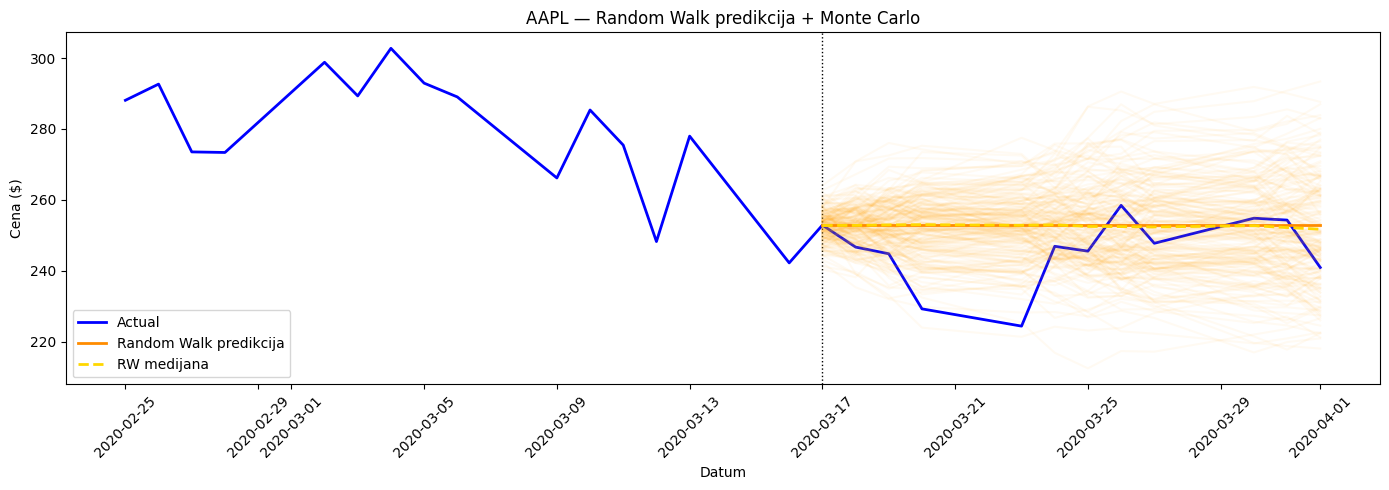

In [12]:
# Random walk - Vizualizacija
ticker = "AAPL"
test_df  = stocks_test[ticker]
train_df = stocks_train[ticker]

last_price = float(test_df["Adj Close"].iloc[0])
test_dates = test_df.index

pre_test = train_df["Adj Close"].iloc[-15:]

rw_cene  = last_price * np.exp(np.cumsum(stocks_rw_preds[ticker]))
rw_paths = last_price * np.exp(np.cumsum(stocks_rw_samples[ticker][0], axis=1))

plt.figure(figsize=(14, 5))
sve_datumi = list(pre_test.index) + list(test_dates)
sve_cene   = list(pre_test.values) + list(test_df["Adj Close"].values)
plt.plot(sve_datumi, sve_cene, color="blue", linewidth=2, label="Actual")
plt.axvline(x=test_dates[0], color="black", linewidth=1, linestyle=":")
for path in rw_paths[:200]:
    plt.plot(test_dates, path, alpha=0.05, color="orange")
plt.plot(test_dates, rw_cene, color="darkorange", linewidth=2, label="Random Walk predikcija")
plt.plot(test_dates, np.median(rw_paths, axis=0), color="gold", linewidth=2, linestyle="--", label="RW medijana")
plt.title(f"{ticker} — Random Walk predikcija + Monte Carlo")
plt.xlabel("Datum")
plt.ylabel("Cena ($)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
################################## A R ( 1 ) ############################################
# Pomocna funkcija — racuna log-prinose iz cena
# log-prinos = ln(P_t / P_{t-1}), stacionaran za razliku od cena

stocks_ar1_preds   = {}   # deterministicke predikcije
stocks_ar1_samples = {}   # Monte Carlo uzorci

for ticker in stocks_train:
    ret_train = get_log_returns(stocks_train[ticker]).reset_index(drop=True)  # log-prinosi bez datumskog indeksa
    
    model = AutoReg(ret_train, lags=1, old_names=False).fit()  # fitujemo AR(1) model na train skupu
    phi   = model.params.values       # koeficijenti: [const, phi_1]
    sigma = np.sqrt(model.sigma2)     # standardna devijacija greske modela
    
    H       = len(stocks_test[ticker])        # horizont predvidjanja
    history = float(ret_train.values[-1])     # poslednji prinos iz train — pocetni uslov
    
    # Deterministicka predikcija — AR(1) formula bez suma: r_t = phi0 + phi1 * r_{t-1}
    path = []
    for h in range(H):
        r_next = phi[0] + phi[1] * history   # AR(1) rekurzija
        path.append(r_next)
        history = r_next                      # azuriramo history za sledeci korak
    stocks_ar1_preds[ticker] = np.array(path)
    
    # Monte Carlo — ista AR(1) formula + slucajni sum
    rng = np.random.default_rng(42)              # fiksirani seed
    S = 1000                                      # broj putanja
    n_windows = max(1, H // 21)                  # broj rolling polazista
    samples   = np.zeros((n_windows, S, H))      # matrica [polazista x putanje x dani]
    init      = float(ret_train.values[-1])      # pocetni prinos
    
    for w in range(n_windows):
        for s in range(S):
            hist    = init
            mc_path = []
            for h in range(H):
                r_next = phi[0] + phi[1] * hist + rng.normal(0, sigma)  # AR(1) + Gaussov sum
                mc_path.append(r_next)
                hist = r_next
            samples[w, s, :] = mc_path
    
    stocks_ar1_samples[ticker] = samples

print("\nSvi AR(1) modeli gotovi.")


Svi AR(1) modeli gotovi.


In [13]:
#METRIKE AR(1)
print("=== AR(1) ===")
ar1_rezultati = []

for ticker in stocks_test:
    actual     = stocks_test[ticker]["Adj Close"].values
    last_price = float(stocks_test[ticker]["Adj Close"].iloc[0])
    paths      = get_price_paths(stocks_ar1_samples[ticker][0], last_price)

    m = {
        "Ticker": ticker,
        "RMSE":   round(rmse(actual, paths), 4),
        "ND":     round(nd(actual, paths), 4),
        "QL_0.9": round(ql(actual, paths, 0.9), 4),
        "QL_0.1": round(ql(actual, paths, 0.1), 4),
    }
    print(f"  {ticker}: RMSE={m['RMSE']}  ND={m['ND']}  QL0.9={m['QL_0.9']}  QL0.1={m['QL_0.1']}")
    ar1_rezultati.append(m)

df_ar1 = pd.DataFrame(ar1_rezultati).set_index("Ticker")
print(f"\n  PROSEK: RMSE={df_ar1['RMSE'].mean():.4f}  ND={df_ar1['ND'].mean():.4f}  "
      f"QL0.9={df_ar1['QL_0.9'].mean():.4f}  QL0.1={df_ar1['QL_0.1'].mean():.4f}\n")

=== AR(1) ===
  AAPL: RMSE=13.6122  ND=0.0414  QL0.9=0.0194  QL0.1=0.0262
  MSFT: RMSE=7.5031  ND=0.0421  QL0.9=0.0132  QL0.1=0.0293
  AMZN: RMSE=90.0018  ND=0.0415  QL0.9=0.0043  QL0.1=0.0193
  GOOGL: RMSE=33.5213  ND=0.0246  QL0.9=0.0123  QL0.1=0.0123
  JPM: RMSE=8.714  ND=0.0838  QL0.9=0.0268  QL0.1=0.0778
  JNJ: RMSE=13.5806  ND=0.091  QL0.9=0.0249  QL0.1=0.1103
  XOM: RMSE=2.4934  ND=0.0526  QL0.9=0.015  QL0.1=0.0551
  PG: RMSE=12.1177  ND=0.0955  QL0.9=0.0259  QL0.1=0.1187
  KO: RMSE=5.6937  ND=0.117  QL0.9=0.0304  QL0.1=0.1538
  PEP: RMSE=14.4848  ND=0.1087  QL0.9=0.0282  QL0.1=0.1421
  WMT: RMSE=6.2817  ND=0.0472  QL0.9=0.0162  QL0.1=0.0311
  INTC: RMSE=3.19  ND=0.0513  QL0.9=0.0178  QL0.1=0.0391
  CSCO: RMSE=2.8011  ND=0.0629  QL0.9=0.0367  QL0.1=0.0203
  ORCL: RMSE=2.0155  ND=0.0362  QL0.9=0.0105  QL0.1=0.0167
  IBM: RMSE=6.0037  ND=0.0437  QL0.9=0.0134  QL0.1=0.0375
  CVX: RMSE=8.9493  ND=0.0995  QL0.9=0.0296  QL0.1=0.1238
  MRK: RMSE=4.1754  ND=0.0479  QL0.9=0.016  QL0.1=0.

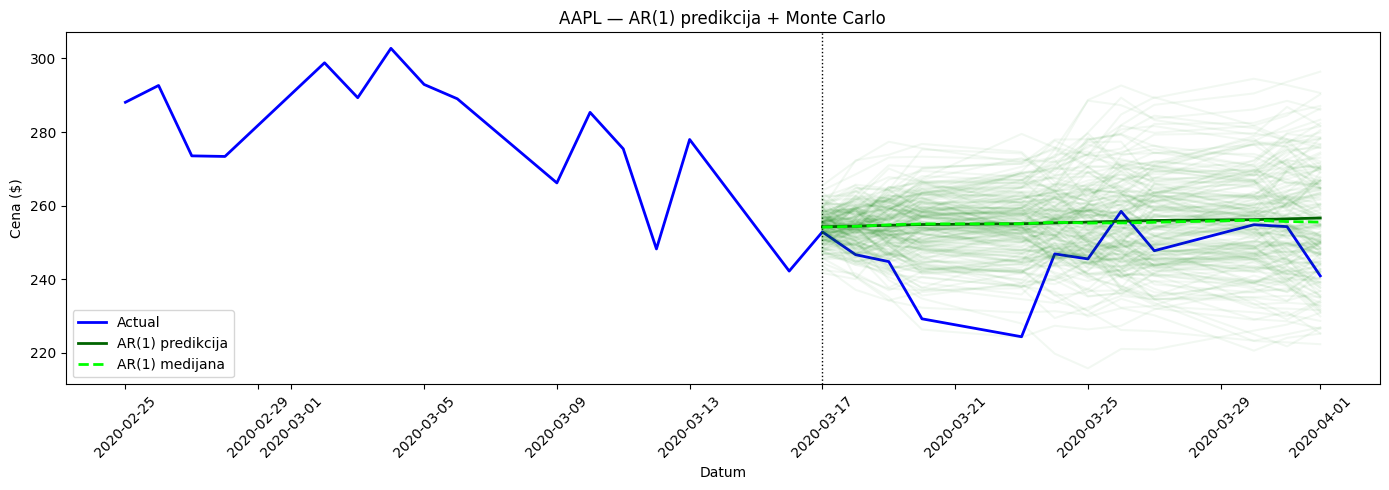

In [14]:
# AR(1) - Vizualizacija
ticker = "AAPL"
test_df  = stocks_test[ticker]
train_df = stocks_train[ticker]

last_price = float(test_df["Adj Close"].iloc[0])
test_dates = test_df.index
pre_test   = train_df["Adj Close"].iloc[-15:]

ar1_cene  = last_price * np.exp(np.cumsum(stocks_ar1_preds[ticker]))
ar1_paths = last_price * np.exp(np.cumsum(stocks_ar1_samples[ticker][0], axis=1))

plt.figure(figsize=(14, 5))
sve_datumi = list(pre_test.index) + list(test_dates)
sve_cene   = list(pre_test.values) + list(test_df["Adj Close"].values)
plt.plot(sve_datumi, sve_cene, color="blue", linewidth=2, label="Actual")
plt.axvline(x=test_dates[0], color="black", linewidth=1, linestyle=":")
for path in ar1_paths[:200]:
    plt.plot(test_dates, path, alpha=0.05, color="green")
plt.plot(test_dates, ar1_cene, color="darkgreen", linewidth=2, label="AR(1) predikcija")
plt.plot(test_dates, np.median(ar1_paths, axis=0), color="lime", linewidth=2, linestyle="--", label="AR(1) medijana")
plt.title(f"{ticker} — AR(1) predikcija + Monte Carlo")
plt.xlabel("Datum")
plt.ylabel("Cena ($)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
####################################### A R I M A ( 1, 0, 1 ) #####################################
stocks_arima_preds   = {}   # deterministicke predikcije
stocks_arima_samples = {}   # Monte Carlo uzorci

for ticker in stocks_train:
    ret_train = get_log_returns(stocks_train[ticker]).reset_index(drop=True)  # log-prinosi iz train skupa
    
    model = ARIMA(ret_train, order=(1, 0, 1)).fit()  # ARIMA(p=1, d=0, q=1) — d=0 jer su log-prinosi vec stacionarni
    
    H = len(stocks_test[ticker])   # horizont predvidjanja
    
    # Deterministicka predikcija — model.forecast vraca ocekivane vrednosti
    forecast = model.forecast(steps=H)
    stocks_arima_preds[ticker] = forecast.values
    
    # Monte Carlo — model.simulate generise slucajne putanje na osnovu fitovanih parametara
    rng = np.random.default_rng(42)              # fiksirani seed
    S = 1000                                      # broj putanja
    n_windows = max(1, H // 21)                  # broj rolling polazista
    samples   = np.zeros((n_windows, S, H))      # matrica [polazista x putanje x dani]
    
    for w in range(n_windows):
        for s in range(S):
            sim = model.simulate(nsimulations=H, random_state=int(rng.integers(1e6)))  # simulira jednu putanju
            samples[w, s, :] = sim.values
    
    stocks_arima_samples[ticker] = samples

print("\nSvi ARIMA modeli gotovi.")


Svi ARIMA modeli gotovi.


In [15]:
#METRIKE ARIMA(1,0,1)
print("=== ARIMA(1,0,1) ===")
arima_rezultati = []

for ticker in stocks_test:
    actual     = stocks_test[ticker]["Adj Close"].values
    last_price = float(stocks_test[ticker]["Adj Close"].iloc[0])
    paths      = get_price_paths(stocks_arima_samples[ticker][0], last_price)

    m = {
        "Ticker": ticker,
        "RMSE":   round(rmse(actual, paths), 4),
        "ND":     round(nd(actual, paths), 4),
        "QL_0.9": round(ql(actual, paths, 0.9), 4),
        "QL_0.1": round(ql(actual, paths, 0.1), 4),
    }
    print(f"  {ticker}: RMSE={m['RMSE']}  ND={m['ND']}  QL0.9={m['QL_0.9']}  QL0.1={m['QL_0.1']}")
    arima_rezultati.append(m)

df_arima = pd.DataFrame(arima_rezultati).set_index("Ticker")
print(f"\n  PROSEK: RMSE={df_arima['RMSE'].mean():.4f}  ND={df_arima['ND'].mean():.4f}  "
      f"QL0.9={df_arima['QL_0.9'].mean():.4f}  QL0.1={df_arima['QL_0.1'].mean():.4f}\n")

=== ARIMA(1,0,1) ===
  AAPL: RMSE=12.7204  ND=0.0377  QL0.9=0.018  QL0.1=0.0244
  MSFT: RMSE=7.282  ND=0.0401  QL0.9=0.0155  QL0.1=0.0229
  AMZN: RMSE=91.321  ND=0.0423  QL0.9=0.004  QL0.1=0.019
  GOOGL: RMSE=32.0293  ND=0.0234  QL0.9=0.0114  QL0.1=0.0115
  JPM: RMSE=7.4543  ND=0.0683  QL0.9=0.0226  QL0.1=0.0641
  JNJ: RMSE=13.1204  ND=0.0869  QL0.9=0.0238  QL0.1=0.1065
  XOM: RMSE=2.4539  ND=0.0519  QL0.9=0.0146  QL0.1=0.0541
  PG: RMSE=11.6896  ND=0.0911  QL0.9=0.0246  QL0.1=0.1148
  KO: RMSE=5.5589  ND=0.1136  QL0.9=0.0294  QL0.1=0.1503
  PEP: RMSE=12.8089  ND=0.0921  QL0.9=0.0246  QL0.1=0.1184
  WMT: RMSE=5.8043  ND=0.0435  QL0.9=0.0159  QL0.1=0.0268
  INTC: RMSE=3.2471  ND=0.054  QL0.9=0.0229  QL0.1=0.0319
  CSCO: RMSE=2.9366  ND=0.0654  QL0.9=0.0447  QL0.1=0.0211
  ORCL: RMSE=2.0832  ND=0.0369  QL0.9=0.0126  QL0.1=0.0152
  IBM: RMSE=5.885  ND=0.0427  QL0.9=0.0137  QL0.1=0.0362
  CVX: RMSE=8.5758  ND=0.0945  QL0.9=0.0288  QL0.1=0.1178
  MRK: RMSE=3.9842  ND=0.0452  QL0.9=0.015  QL

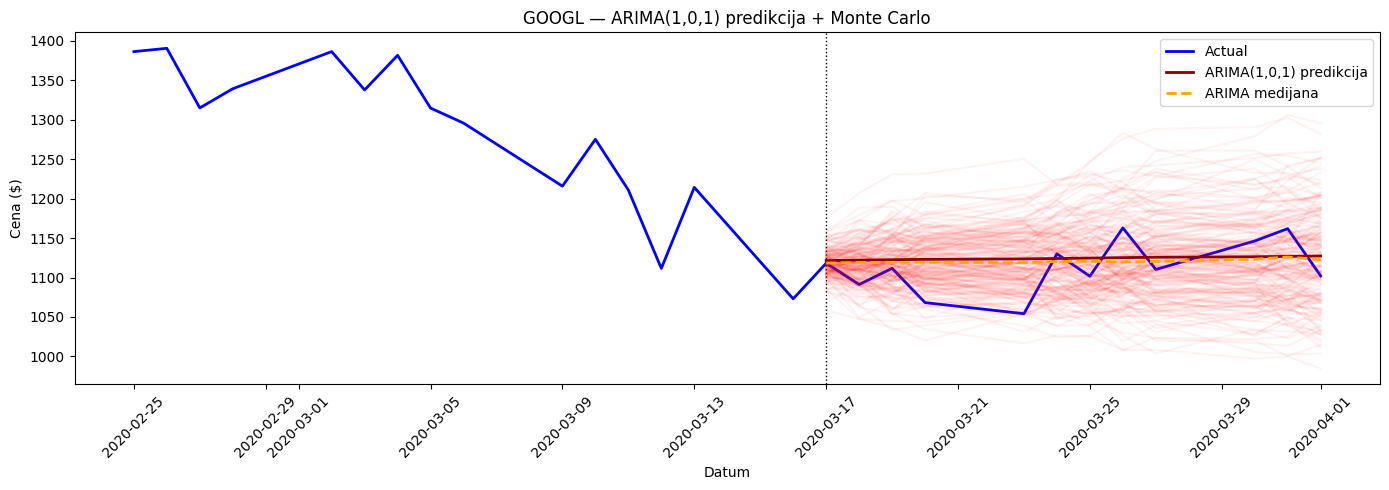

In [39]:
# ARIMA(1,0,1) - Vizualizacija
ticker = "GOOGL"
test_df  = stocks_test[ticker]
train_df = stocks_train[ticker]

last_price = float(test_df["Adj Close"].iloc[0])
test_dates = test_df.index
pre_test   = train_df["Adj Close"].iloc[-15:]

arima_cene  = last_price * np.exp(np.cumsum(stocks_arima_preds[ticker]))
arima_paths = last_price * np.exp(np.cumsum(stocks_arima_samples[ticker][0], axis=1))

plt.figure(figsize=(14, 5))
sve_datumi = list(pre_test.index) + list(test_dates)
sve_cene   = list(pre_test.values) + list(test_df["Adj Close"].values)
plt.plot(sve_datumi, sve_cene, color="blue", linewidth=2, label="Actual")
plt.axvline(x=test_dates[0], color="black", linewidth=1, linestyle=":")
for path in arima_paths[:200]:
    plt.plot(test_dates, path, alpha=0.05, color="red")
plt.plot(test_dates, arima_cene, color="darkred", linewidth=2, label="ARIMA(1,0,1) predikcija")
plt.plot(test_dates, np.median(arima_paths, axis=0), color="orange", linewidth=2, linestyle="--", label="ARIMA medijana")
plt.title(f"{ticker} — ARIMA(1,0,1) predikcija + Monte Carlo")
plt.xlabel("Datum")
plt.ylabel("Cena ($)")
plt.legend()
# plt.ylim(220, 305)  ← uklonili smo ovo
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
####################################### G A R C H ( 1, 1 ) #####################################
stocks_garch_preds   = {}   # deterministicke predikcije
stocks_garch_samples = {}   # Monte Carlo uzorci

for ticker in stocks_train:
    ret_train  = get_log_returns(stocks_train[ticker]).reset_index(drop=True)  # log-prinosi iz train
    ret_scaled = ret_train * 100   # skaliramo na % — arch biblioteka bolje konvergira sa vecim brojevima
    
    model = arch_model(ret_scaled, vol="Garch", p=1, q=1, dist="normal").fit(disp="off")  # GARCH(1,1) sa Gaussovom raspodelom
    
    H = len(stocks_test[ticker])   # horizont predvidjanja
    
    # Deterministicka predikcija — mu (srednja vrednost) ponovljena H puta, skalirana nazad
    mu = model.params["mu"]
    stocks_garch_preds[ticker] = np.full(H, mu / 100)   # delimo sa 100 da vratimo na decimale
    
    # Monte Carlo — rucna simulacija GARCH(1,1) procesa
    rng = np.random.default_rng(42)              # fiksirani seed
    S = 1000                                      # broj putanja
    n_windows = max(1, H // 21)                  # broj rolling polazista
    samples   = np.zeros((n_windows, S, H))      # matrica [polazista x putanje x dani]
    
    omega = model.params["omega"]     # konstanta u GARCH jednacini
    alpha = model.params["alpha[1]"]  # koeficijent kvadrata prinosa (reakcija na sok)
    beta  = model.params["beta[1]"]   # koeficijent prethodne varijanse (persistentnost)
    
    last_var = model.conditional_volatility.iloc[-1] ** 2  # poslednja uslovna varijansa iz train
    last_ret = float(ret_scaled.iloc[-1])                  # poslednji prinos iz train
    
    for w in range(n_windows):
        for s in range(S):
            sigma2 = last_var   # pocetna varijansa
            prev_r = last_ret   # pocetni prinos
            path   = []
            
            for h in range(H):
                sigma2 = omega + alpha * prev_r**2 + beta * sigma2   # GARCH(1,1) rekurzija za varijansu
                r_next = mu + np.sqrt(sigma2) * rng.normal(0, 1)     # novi prinos = mu + volatilnost * N(0,1)
                path.append(r_next)
                prev_r = r_next
            
            samples[w, s, :] = np.array(path) / 100   # skaliramo nazad na decimale
    
    stocks_garch_samples[ticker] = samples

print("\nSvi GARCH modeli gotovi.")


Svi GARCH modeli gotovi.


In [33]:
#METRIKE GARCH(1,1)
print("=== GARCH(1,1) ===")
garch_rezultati = []

for ticker in stocks_test:
    actual     = stocks_test[ticker]["Adj Close"].values
    last_price = float(stocks_test[ticker]["Adj Close"].iloc[0])
    paths      = get_price_paths(stocks_garch_samples[ticker][0], last_price)

    m = {
        "Ticker": ticker,
        "RMSE":   round(rmse(actual, paths), 4),
        "ND":     round(nd(actual, paths), 4),
        "QL_0.9": round(ql(actual, paths, 0.9), 4),
        "QL_0.1": round(ql(actual, paths, 0.1), 4),
    }
    print(f"  {ticker}: RMSE={m['RMSE']}  ND={m['ND']}  QL0.9={m['QL_0.9']}  QL0.1={m['QL_0.1']}")
    garch_rezultati.append(m)

df_garch = pd.DataFrame(garch_rezultati).set_index("Ticker")
print(f"\n  PROSEK: RMSE={df_garch['RMSE'].mean():.4f}  ND={df_garch['ND'].mean():.4f}  "
      f"QL0.9={df_garch['QL_0.9'].mean():.4f}  QL0.1={df_garch['QL_0.1'].mean():.4f}\n")

=== GARCH(1,1) ===
  AAPL: RMSE=13.4073  ND=0.0397  QL0.9=0.0575  QL0.1=0.0305
  MSFT: RMSE=7.6799  ND=0.0424  QL0.9=0.0499  QL0.1=0.0392
  AMZN: RMSE=87.0586  ND=0.0398  QL0.9=0.0185  QL0.1=0.0298
  GOOGL: RMSE=34.146  ND=0.0245  QL0.9=0.0346  QL0.1=0.0257
  JPM: RMSE=7.5467  ND=0.0689  QL0.9=0.0784  QL0.1=0.0353
  JNJ: RMSE=13.0891  ND=0.0858  QL0.9=0.0449  QL0.1=0.0347
  XOM: RMSE=2.5543  ND=0.055  QL0.9=0.049  QL0.1=0.0288
  PG: RMSE=11.6618  ND=0.0904  QL0.9=0.0528  QL0.1=0.0234
  KO: RMSE=5.5918  ND=0.1138  QL0.9=0.0462  QL0.1=0.0656
  PEP: RMSE=12.8728  ND=0.0916  QL0.9=0.0595  QL0.1=0.0277
  WMT: RMSE=5.917  ND=0.0444  QL0.9=0.0273  QL0.1=0.009
  INTC: RMSE=3.4575  ND=0.0581  QL0.9=0.0529  QL0.1=0.0451
  CSCO: RMSE=3.0137  ND=0.067  QL0.9=0.0245  QL0.1=0.0414
  ORCL: RMSE=2.268  ND=0.0401  QL0.9=0.0488  QL0.1=0.0416
  IBM: RMSE=6.1012  ND=0.0441  QL0.9=0.0341  QL0.1=0.0229
  CVX: RMSE=8.7134  ND=0.096  QL0.9=0.0728  QL0.1=0.0598
  MRK: RMSE=4.1105  ND=0.0465  QL0.9=0.0309  QL0.

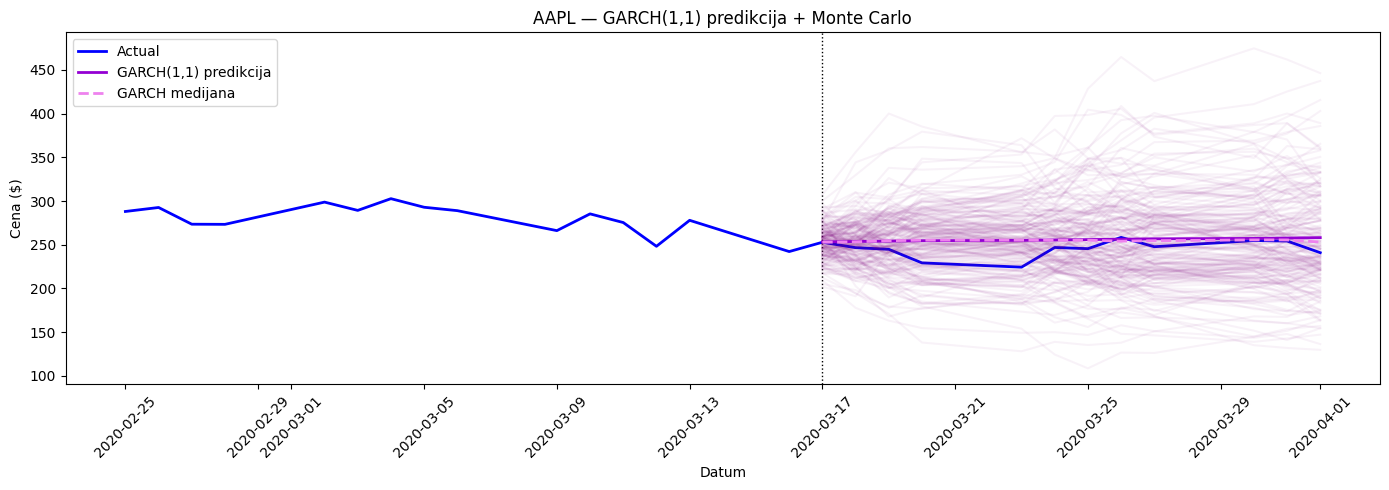

In [40]:
# GARCH(1,1) - Vizualizacija
ticker = "AAPL"
test_df  = stocks_test[ticker]
train_df = stocks_train[ticker]

last_price = float(test_df["Adj Close"].iloc[0])
test_dates = test_df.index
pre_test   = train_df["Adj Close"].iloc[-15:]

garch_cene  = last_price * np.exp(np.cumsum(stocks_garch_preds[ticker]))
garch_paths = last_price * np.exp(np.cumsum(stocks_garch_samples[ticker][0], axis=1))

plt.figure(figsize=(14, 5))
sve_datumi = list(pre_test.index) + list(test_dates)
sve_cene   = list(pre_test.values) + list(test_df["Adj Close"].values)
plt.plot(sve_datumi, sve_cene, color="blue", linewidth=2, label="Actual")
plt.axvline(x=test_dates[0], color="black", linewidth=1, linestyle=":")
for path in garch_paths[:200]:
    plt.plot(test_dates, path, alpha=0.05, color="purple")
plt.plot(test_dates, garch_cene, color="darkviolet", linewidth=2, label="GARCH(1,1) predikcija")
plt.plot(test_dates, np.median(garch_paths, axis=0), color="violet", linewidth=2, linestyle="--", label="GARCH medijana")
plt.title(f"{ticker} — GARCH(1,1) predikcija + Monte Carlo")
plt.xlabel("Datum")
plt.ylabel("Cena ($)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# Funkcije za metrike
'''
def rmse(actual, pred):
    # RMSE — koren srednje kvadratne greske, kaznjava vece greske vise
    return np.sqrt(mean_squared_error(actual, pred))

def mae(actual, pred):
    # MAE — srednja apsolutna greska, manje osetljiva na ekstreme od RMSE
    return mean_absolute_error(actual, pred)

def coverage(actual, samples, q_low=5, q_high=95):
    # Coverage — koliko puta stvarna cena pada unutar 90% intervala poverenja (5-95 percentil)
    # Idealno: 90% — ako je manje, model potcenjuje rizik
    low    = np.percentile(samples, q_low,  axis=0)   # donja granica intervala
    high   = np.percentile(samples, q_high, axis=0)   # gornja granica intervala
    inside = (actual >= low) & (actual <= high)        # True/False — da li je stvarna vrednost unutar
    return inside.mean() * 100   # u procentima

def interval_width(samples, q_low=5, q_high=95):
    # Interval Width — prosecna sirina 90% intervala poverenja
    # Uzi interval = sigurniji model (ako coverage drzi)
    low  = np.percentile(samples, q_low,  axis=0)
    high = np.percentile(samples, q_high, axis=0)
    return (high - low).mean()


# Racunamo metrike za sve modele i sve tikere
rezultati = []

for ticker in stocks_test:
    actual     = stocks_test[ticker]["Adj Close"].values          # stvarne cene u test periodu
    last_price = float(stocks_test[ticker]["Adj Close"].iloc[0])  # pocetna cena za skaliranje
    H          = len(actual)                                       # broj dana u test skupu

    # Pretvaramo log-prinose u cene za svaki model
    rw_cene    = last_price * np.exp(np.cumsum(stocks_rw_preds[ticker]))[:H]
    rw_paths   = last_price * np.exp(np.cumsum(stocks_rw_samples[ticker][0], axis=1))

    ar1_cene   = last_price * np.exp(np.cumsum(stocks_ar1_preds[ticker]))[:H]
    ar1_paths  = last_price * np.exp(np.cumsum(stocks_ar1_samples[ticker][0], axis=1))

    arima_cene  = last_price * np.exp(np.cumsum(stocks_arima_preds[ticker]))[:H]
    arima_paths = last_price * np.exp(np.cumsum(stocks_arima_samples[ticker][0], axis=1))

    garch_cene  = last_price * np.exp(np.cumsum(stocks_garch_preds[ticker]))[:H]
    garch_paths = last_price * np.exp(np.cumsum(stocks_garch_samples[ticker][0], axis=1))


    for model_name, cene, paths in [
        ("Random Walk",    rw_cene,    rw_paths),
        ("AR(1)",          ar1_cene,   ar1_paths),
        ("ARIMA(1,0,1)",   arima_cene, arima_paths),
        ("GARCH(1,1)",     garch_cene, garch_paths),
    ]:
        min_H = min(len(actual), len(cene), paths.shape[1])   # osiguravamo iste duzine
        
        rezultati.append({
            "Ticker":    ticker,
            "Model":     model_name,
            "RMSE":      round(rmse(actual[:min_H], cene[:min_H]), 4),
            "MAE":       round(mae(actual[:min_H], cene[:min_H]), 4),
            "Coverage":  round(coverage(actual[:min_H], paths[:, :min_H]), 1),
            "Avg Width": round(interval_width(paths[:, :min_H]), 4),
        })

df_rezultati = pd.DataFrame(rezultati)
print(df_rezultati)
# Prosek metrika po modelu (jedna vrednost po modelu, prosecena kroz svih 30 tikera)
df_avg = df_rezultati.groupby("Model")[["RMSE","MAE","Coverage","Avg Width"]].mean().round(2)
print(df_avg)
'''

'\ndef rmse(actual, pred):\n    # RMSE — koren srednje kvadratne greske, kaznjava vece greske vise\n    return np.sqrt(mean_squared_error(actual, pred))\n\ndef mae(actual, pred):\n    # MAE — srednja apsolutna greska, manje osetljiva na ekstreme od RMSE\n    return mean_absolute_error(actual, pred)\n\ndef coverage(actual, samples, q_low=5, q_high=95):\n    # Coverage — koliko puta stvarna cena pada unutar 90% intervala poverenja (5-95 percentil)\n    # Idealno: 90% — ako je manje, model potcenjuje rizik\n    low    = np.percentile(samples, q_low,  axis=0)   # donja granica intervala\n    high   = np.percentile(samples, q_high, axis=0)   # gornja granica intervala\n    inside = (actual >= low) & (actual <= high)        # True/False — da li je stvarna vrednost unutar\n    return inside.mean() * 100   # u procentima\n\ndef interval_width(samples, q_low=5, q_high=95):\n    # Interval Width — prosecna sirina 90% intervala poverenja\n    # Uzi interval = sigurniji model (ako coverage drzi)\n